In [1]:
print("Initialization")

Initialization


In [2]:
import modified_didppy as m_dp
import numpy as np
import time
import matplotlib.pyplot as plt

In [3]:


# ==========================================
# 1. DATA (N=20)
# ==========================================
DISTANCE_MATRIX = [
    [0, 34, 48, 30, 50, 10, 28, 41, 32, 4, 53, 62, 22, 59, 38, 36, 36, 37, 2, 13], 
    [34, 0, 33, 4, 83, 34, 42, 69, 56, 35, 63, 30, 44, 39, 49, 5, 53, 70, 35, 31], 
    [48, 33, 0, 35, 94, 41, 70, 90, 49, 46, 40, 55, 67, 72, 33, 28, 80, 73, 50, 54], 
    [30, 4, 35, 0, 79, 30, 38, 65, 53, 31, 62, 34, 40, 40, 48, 8, 50, 66, 31, 27], 
    [50, 83, 94, 79, 0, 54, 54, 28, 53, 50, 81, 109, 45, 97, 70, 86, 50, 27, 48, 54], 
    [10, 34, 41, 30, 54, 0, 38, 50, 24, 7, 44, 64, 32, 64, 28, 35, 46, 37, 12, 22], 
    [28, 42, 70, 38, 54, 38, 0, 31, 60, 32, 82, 58, 10, 43, 66, 47, 11, 56, 27, 16], 
    [41, 69, 90, 65, 28, 50, 31, 0, 61, 44, 88, 90, 26, 73, 74, 73, 24, 43, 40, 38], 
    [32, 56, 49, 53, 53, 24, 60, 61, 0, 28, 28, 86, 51, 89, 18, 55, 66, 27, 33, 45], 
    [4, 35, 46, 31, 50, 7, 32, 44, 28, 0, 50, 64, 25, 62, 34, 36, 40, 36, 5, 17], 
    [53, 63, 40, 62, 81, 44, 82, 88, 28, 50, 0, 91, 75, 101, 16, 60, 90, 54, 55, 66], 
    [62, 30, 55, 34, 109, 64, 58, 90, 86, 64, 91, 0, 65, 27, 79, 32, 68, 99, 63, 55], 
    [22, 44, 67, 40, 45, 32, 10, 26, 51, 25, 75, 65, 0, 52, 59, 48, 15, 46, 20, 13], 
    [59, 39, 72, 40, 97, 64, 43, 73, 89, 62, 101, 27, 52, 0, 87, 44, 50, 94, 59, 47], 
    [38, 49, 33, 48, 70, 28, 66, 74, 18, 34, 16, 79, 59, 87, 0, 47, 74, 45, 39, 50], 
    [36, 5, 28, 8, 86, 35, 47, 73, 55, 36, 60, 32, 48, 44, 47, 0, 58, 71, 37, 35], 
    [36, 53, 80, 50, 50, 46, 11, 24, 66, 40, 90, 68, 15, 50, 74, 58, 0, 57, 35, 26], 
    [37, 70, 73, 66, 27, 37, 56, 43, 27, 36, 54, 99, 46, 94, 45, 71, 57, 0, 37, 48], 
    [2, 35, 50, 31, 48, 12, 27, 40, 33, 5, 55, 63, 20, 59, 39, 37, 35, 37, 0, 13], 
    [13, 31, 54, 27, 54, 22, 16, 38, 45, 17, 66, 55, 13, 47, 50, 35, 26, 48, 13, 0]
]
n = 20
OPTIMAL_COST_REFERENCE = 400

# ==========================================
# 2. PROFILING FUNCTIONS
# ==========================================
def run_solver_with_profiling(solver, time_limit_seconds=60):
    """
    Runs the solver iteratively using search_next() and records (nodes, cost).
    This captures the 'Anytime' behavior of CABS.
    """
    history = []
    # Initial state: 0 nodes, Infinite cost (Gap 100%)
    history.append((0, float('inf'))) 
    
    start_time = time.time()
    print(f"   -> Profiling started (Limit: {time_limit_seconds}s)...")
    
    while True:
        try:
            # 1. Search for the next improved solution
            # CABS returns immediately if it finds a better solution OR finishes a beam layer
            solution, is_terminated = solver.search_next()
            
            # 2. Record if a valid solution exists
            if solution.cost is not None:
                history.append((solution.expanded, solution.cost))
            
            # 3. Check termination conditions
            if is_terminated:
                print("   -> Solver finished (Optimality Proven or Infeasible).")
                break
                
            if (time.time() - start_time) > time_limit_seconds:
                print("   -> Time limit reached.")
                break
                
        except Exception as e:
            print(f"   -> Solver stopped due to error: {e}")
            break
            
    return history

def generate_gap_curve(history, max_node_limit, optimal_cost):
    """
    Converts sparse history [(100, 500), (5000, 450)] into a dense array 
    of gaps for every single integer node count from 1 to max_node_limit.
    """
    gaps = []
    
    # Sort history by expanded nodes (just in case)
    history.sort(key=lambda x: x[0])
    
    current_best = float('inf')
    hist_idx = 0
    
    # Iterate for every integer node count from 1 to Limit
    # This "fills in the blanks" between solver reports
    for l in range(1, max_node_limit + 1):
        
        # Check if the solver found a better solution by this node count 'l'
        while hist_idx < len(history) and history[hist_idx][0] <= l:
            if history[hist_idx][1] < current_best:
                current_best = history[hist_idx][1]
            hist_idx += 1
        
        # Calculate Gap
        if current_best == float('inf'): 
            gap = 100.0
        else: 
            gap = abs(current_best - optimal_cost) / optimal_cost * 100.0
            
        gaps.append(gap)
        
    return gaps

# ==========================================
# 3. MODEL CREATION (Original)
# ==========================================
def create_standard_model():
    """Creates the N=20 TSP model with Standard Dual Bounds (Min-Flow)."""
    model = m_dp.Model(maximize=False, float_cost=False)
    customer = model.add_object_type(number=n)
    unvisited = model.add_set_var(object_type=customer, target=list(range(1, n)))
    location = model.add_element_var(object_type=customer, target=0)
    travel_time = model.add_int_table(DISTANCE_MATRIX)

    # Transitions
    for j in range(1, n):
        visit = m_dp.Transition(
            name=f"visit {j}",
            cost=travel_time[location, j] + m_dp.IntExpr.state_cost(),
            preconditions=[unvisited.contains(j)],
            effects=[(unvisited, unvisited.remove(j)), (location, j)],
        )
        model.add_transition(visit)

    return_to_depot = m_dp.Transition(
        name="return",
        cost=travel_time[location, 0] + m_dp.IntExpr.state_cost(),
        effects=[(location, 0)],
        preconditions=[unvisited.is_empty(), location != 0],
    )
    model.add_transition(return_to_depot)
    model.add_base_case([unvisited.is_empty(), location == 0])
    
    # --- STANDARD DUAL BOUNDS (Min Flow) ---
    c = np.array(DISTANCE_MATRIX)
    min_to = model.add_int_table([min(c[k][j] for k in range(n) if k != j) for j in range(n)])
    min_from = model.add_int_table([min(c[j][k] for k in range(n) if k != j) for j in range(n)])
    
    model.add_dual_bound(min_to[unvisited] + (location != 0).if_then_else(min_to[0], 0))
    model.add_dual_bound(min_from[unvisited] + (location != 0).if_then_else(min_from[location], 0))
    
    return model



In [ ]:
# ==========================================
# 4. EXECUTION
# ==========================================
print("\n--- TEST: Original CABS Profiling (10,000 Nodes) ---")

# A. Initialize
print("1. Creating Original Model...")
model_orig = create_standard_model()
solver_orig = m_dp.CABS(model_orig, quiet=True)



--- TEST: Original CABS Profiling (10,000 Nodes) ---
1. Creating Original Model...


In [5]:
# B. Profile
print("2. Running Profiling Loop...")
# Run for enough time to ensure it solves or reaches 10k nodes
hist_orig = run_solver_with_profiling(solver_orig, time_limit_seconds=10)

2. Running Profiling Loop...
   -> Profiling started (Limit: 10s)...
   -> Solver finished (Optimality Proven or Infeasible).


In [7]:
hist_orig

[(0, inf), (20, 407), (556, 401), (2189, 400), (3346822, 400)]

3. Generating Gap Analysis (Limit: 10000 nodes)...
4. Plotting...


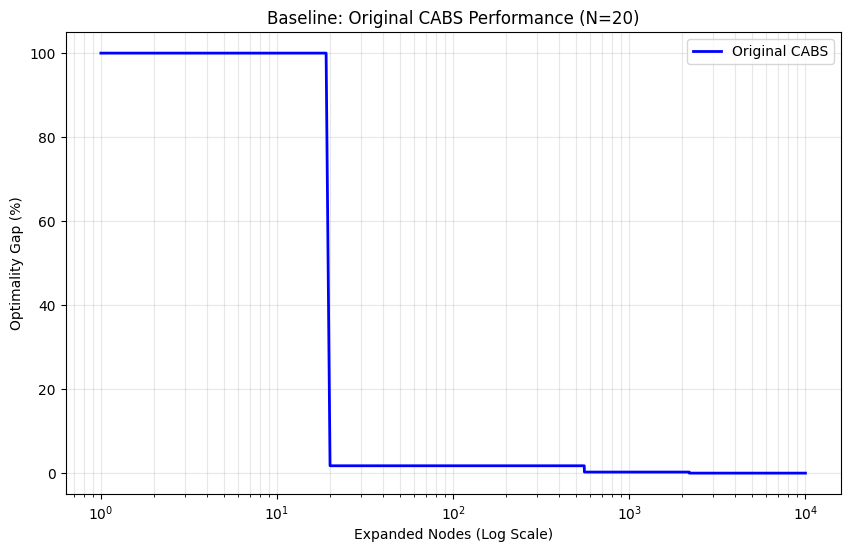


--- Checkpoints ---
Nodes      | Gap (%)   
10         | 100.00%
100        | 1.75%
1000       | 0.25%
10000      | 0.00%


In [6]:
# C. Analyze
MAX_NODES_TO_TEST = 10000 
print(f"3. Generating Gap Analysis (Limit: {MAX_NODES_TO_TEST} nodes)...")
gaps_orig = generate_gap_curve(hist_orig, MAX_NODES_TO_TEST, OPTIMAL_COST_REFERENCE)

# D. Plot
print("4. Plotting...")
plt.figure(figsize=(10, 6))
x_axis = range(1, MAX_NODES_TO_TEST + 1)

plt.semilogx(x_axis, gaps_orig, label='Original CABS', color='blue', linewidth=2)

plt.xlabel('Expanded Nodes (Log Scale)')
plt.ylabel('Optimality Gap (%)')
plt.title(f'Baseline: Original CABS Performance (N={n})')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

# E. Print Table
print("\n--- Checkpoints ---")
checkpoints = [10, 100, 1000, 10000]
print(f"{'Nodes':<10} | {'Gap (%)':<10}")
for cp in checkpoints:
    if cp <= MAX_NODES_TO_TEST:
        print(f"{cp:<10} | {gaps_orig[cp-1]:.2f}%")